# D?tection et classification automatique de maladies des plantes

## Notebook final du projet universitaire

Ce notebook est la version principale ? rendre. Il est pens? pour ?tre ex?cut? **cellule par cellule** dans Jupyter.

Le pipeline suit le cahier des charges:
- pr?traitement des images,
- analyse visuelle et histogrammes,
- segmentation et d?tection de contours,
- extraction de caract?ristiques classiques,
- classification par Machine Learning,
- comparaison avec un mod?le Deep Learning valid?.

## 1. Strat?gie choisie

Pour rester simple, propre et cr?dible acad?miquement, le projet est centr? sur **4 classes de feuilles de tomate** du dataset PlantVillage:
- `Tomato___healthy`
- `Tomato___Early_blight`
- `Tomato___Late_blight`
- `Tomato___Leaf_Mold`

Choix m?thodologiques:
- la partie **classique** utilise des features de couleur, texture et forme;
- la partie **ML** s?lectionne le meilleur mod?le sur le jeu de validation;
- la partie **DL** r?utilise un mod?le `MobileNetV3` d?j? entra?n? et v?rifi? dans `artifacts_final/` pour ?viter un notebook trop long ? ex?cuter.

Cette organisation donne un rendu plus s?rieux qu'un notebook monolithique difficile ? relancer.

In [2]:
# 2. Imports
from pathlib import Path
import json
import math
import time
import warnings

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageOps
from IPython.display import display, Markdown
from scipy import ndimage as ndi
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import threshold_otsu

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['axes.grid'] = False
print('Imports charges avec succes.')

Imports charges avec succes.


In [3]:
# 3. Parametres du notebook et resolution des chemins
FAST_MODE = False
IMAGE_SIZE = 128
REBUILD_FEATURE_CACHE = False


def resolve_project_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / 'prepared_tomato_data').exists() and (candidate / 'artifacts_final').exists():
            return candidate
    return start


PROJECT_ROOT = resolve_project_root()
DATA_ROOT = PROJECT_ROOT / 'prepared_tomato_data'
ARTIFACT_ROOT = PROJECT_ROOT / 'artifacts_final'
CLASSICAL_ROOT = ARTIFACT_ROOT / 'classical_ml'
FEATURE_CACHE_PATH = CLASSICAL_ROOT / 'feature_cache.npz'
DL_SUMMARY_PATH = ARTIFACT_ROOT / 'summary.json'

assert DATA_ROOT.exists(), f'Dossier dataset introuvable: {DATA_ROOT}'
assert ARTIFACT_ROOT.exists(), f'Dossier artifacts introuvable: {ARTIFACT_ROOT}'
CLASSICAL_ROOT.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT =', PROJECT_ROOT)
print('DATA_ROOT =', DATA_ROOT)
print('ARTIFACT_ROOT =', ARTIFACT_ROOT)
print('FEATURE_CACHE_PATH =', FEATURE_CACHE_PATH)

PROJECT_ROOT = c:\Users\gharsalli hind\Desktop\Projet_Ing_img
DATA_ROOT = c:\Users\gharsalli hind\Desktop\Projet_Ing_img\prepared_tomato_data
ARTIFACT_ROOT = c:\Users\gharsalli hind\Desktop\Projet_Ing_img\artifacts_final
FEATURE_CACHE_PATH = c:\Users\gharsalli hind\Desktop\Projet_Ing_img\artifacts_final\classical_ml\feature_cache.npz


## 2. Verification du dataset

On commence par v?rifier les volumes du dataset pr?par?. Cela permet de confirmer que les dossiers `train`, `val` et `test` sont bien pr?sents et coh?rents.

In [4]:
# 4. Comptage des images par split et par classe
SPLITS = ['train', 'val', 'test']
CLASS_NAMES = sorted([p.name for p in (DATA_ROOT / 'train').iterdir() if p.is_dir()])
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

count_rows = []
for split in SPLITS:
    row = {'split': split}
    for class_name in CLASS_NAMES:
        row[class_name] = len(list((DATA_ROOT / split / class_name).glob('*.*')))
    count_rows.append(row)

counts_df = pd.DataFrame(count_rows).set_index('split')
display(counts_df)
print("Nombre total d'images =", int(counts_df.to_numpy().sum()))

,Tomato___Early_blight,Tomato___Late_blight,Tomato___Leaf_Mold,Tomato___healthy
split,,,,
train,625,1228,624,1009
val,160,306,156,252
test,215,375,172,330


Nombre total d'images = 5452


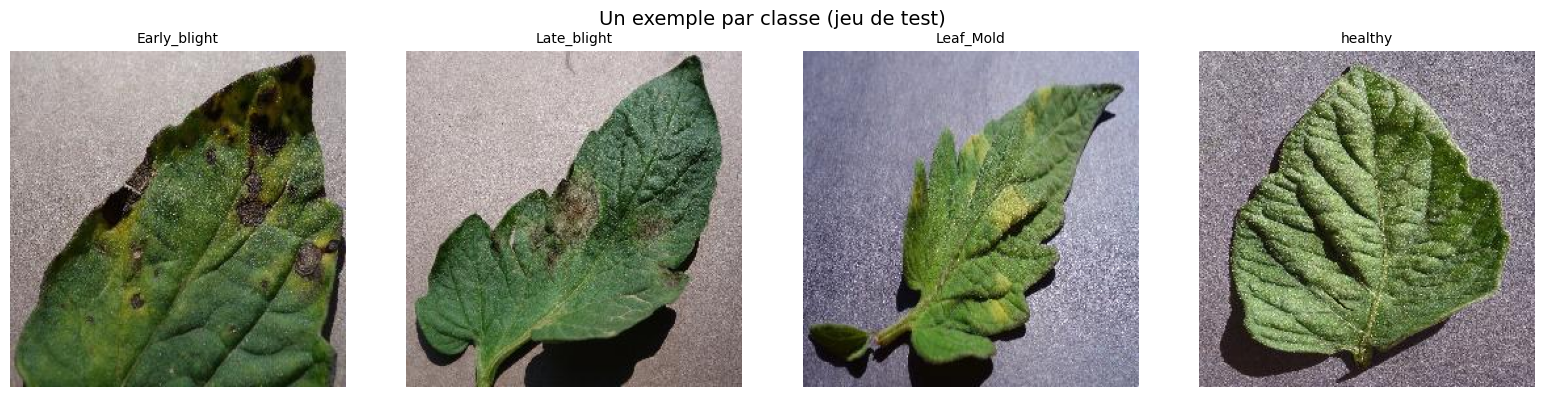

In [5]:
# 5. Apercu visuel rapide des 4 classes
fig, axes = plt.subplots(1, len(CLASS_NAMES), figsize=(16, 4))
for ax, class_name in zip(axes, CLASS_NAMES):
    sample_path = sorted((DATA_ROOT / 'test' / class_name).glob('*.*'))[0]
    image = Image.open(sample_path).convert('RGB')
    ax.imshow(image)
    ax.set_title(class_name.replace('Tomato___', ''), fontsize=10)
    ax.axis('off')
plt.suptitle('Un exemple par classe (jeu de test)', fontsize=14)
plt.tight_layout()
plt.show()

**Lecture rapide**

Le projet est bien limit? ? **4 classes**, ce qui correspond au format individuel demand?. Le dataset pr?par? est d?j? s?par? en `train/val/test`, ce qui simplifie l'?valuation et rend la comparaison plus propre.

## 3. Pretraitement des images

Le pr?traitement retenu est volontairement simple et d?fendable:
- redimensionnement ? `128 x 128`,
- correction d'orientation ?ventuelle,
- filtrage m?dian l?ger pour r?duire le bruit impulsionnel,
- pr?paration de vues `RGB`, `HSV` et `grayscale` selon le besoin.

In [8]:
# 6. Fonctions utilitaires de pretraitement

def preprocess_image(image: Image.Image, image_size: int = IMAGE_SIZE, denoise: bool = True) -> Image.Image:
    image = ImageOps.exif_transpose(image).convert('RGB')
    image = image.resize((image_size, image_size), resample=Image.BILINEAR)
    if denoise:
        image = image.filter(ImageFilter.MedianFilter(size=3))
    return image


def image_to_gray_array(image: Image.Image) -> np.ndarray:
    return np.array(image.convert('L'))


def image_to_hsv_array(image: Image.Image) -> np.ndarray:
    rgb = np.array(image)
    return cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)


def plot_rgb_hsv_histograms(image: Image.Image) -> None:
    rgb = np.array(image).astype(np.float32) / 255.0
    hsv = image_to_hsv_array(image).astype(np.float32)
    hsv[..., 0] /= 179.0
    hsv[..., 1] /= 255.0
    hsv[..., 2] /= 255.0

    fig, axes = plt.subplots(2, 3, figsize=(12, 6))
    rgb_meta = [('R', 'red'), ('G', 'green'), ('B', 'blue')]
    hsv_meta = [('H', 'orange'), ('S', 'purple'), ('V', 'gray')]

    for i, (label, color) in enumerate(rgb_meta):
        axes[0, i].hist(rgb[:, :, i].ravel(), bins=20, color=color, alpha=0.85)
        axes[0, i].set_title(f'Histogramme {label}')
        axes[0, i].grid(alpha=0.2)

    for i, (label, color) in enumerate(hsv_meta):
        axes[1, i].hist(hsv[:, :, i].ravel(), bins=20, color=color, alpha=0.85)
        axes[1, i].set_title(f'Histogramme {label}')
        axes[1, i].grid(alpha=0.2)

    plt.tight_layout()
    plt.show()

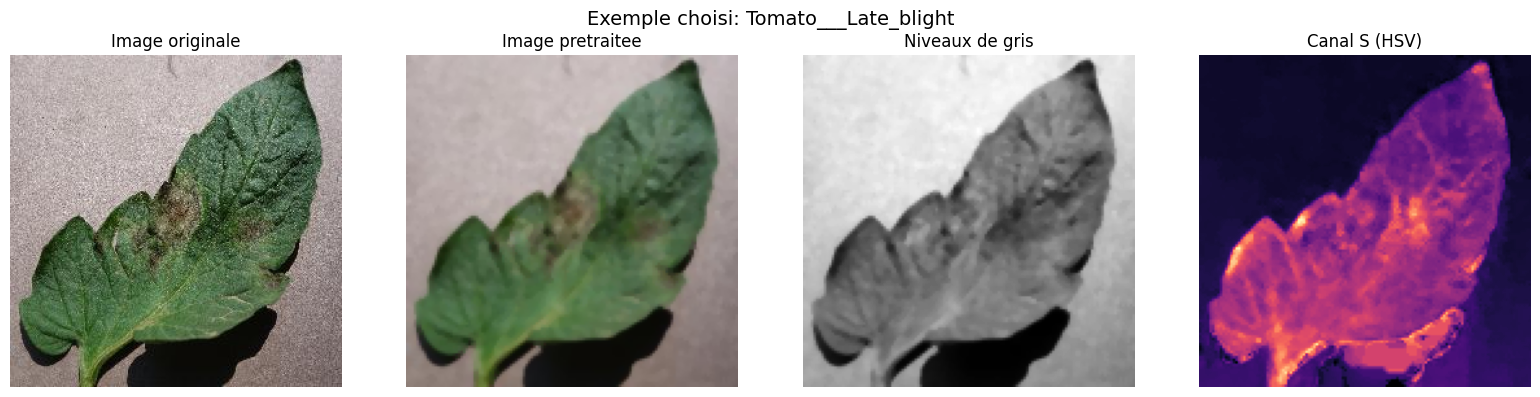

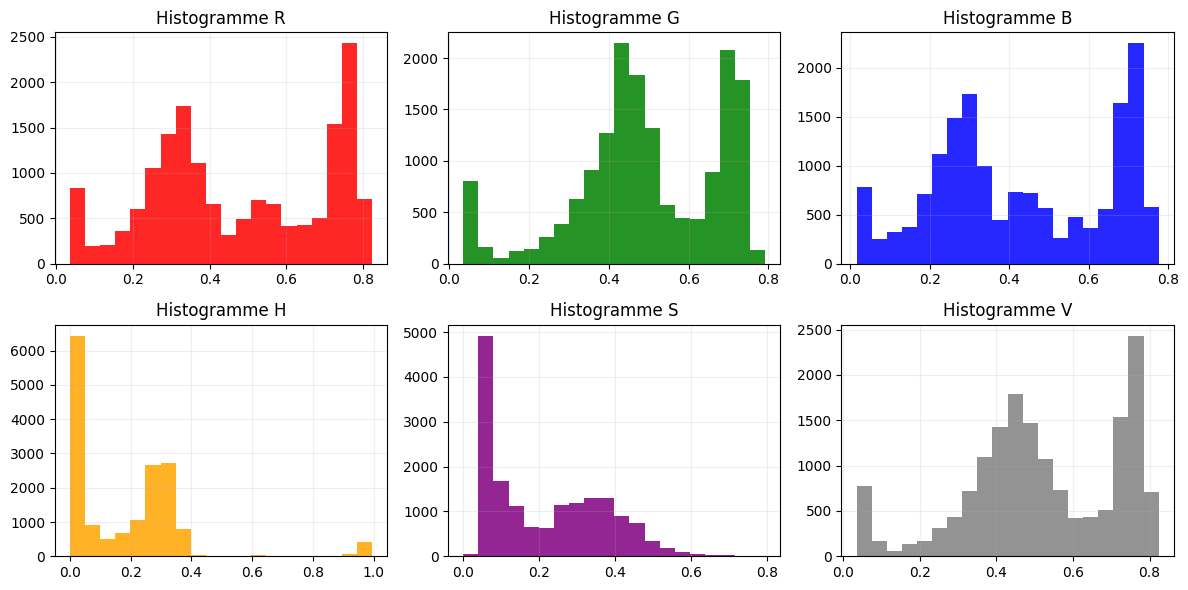

In [9]:
# 7. Exemple avant / apres pretraitement
preferred_class = 'Tomato___Late_blight' if 'Tomato___Late_blight' in CLASS_NAMES else CLASS_NAMES[0]
example_path = sorted((DATA_ROOT / 'test' / preferred_class).glob('*.*'))[0]
original_image = Image.open(example_path).convert('RGB')
processed_image = preprocess_image(original_image)
gray_image = image_to_gray_array(processed_image)
hsv_image = image_to_hsv_array(processed_image)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(original_image)
axes[0].set_title('Image originale')
axes[1].imshow(processed_image)
axes[1].set_title('Image pretraitee')
axes[2].imshow(gray_image, cmap='gray')
axes[2].set_title('Niveaux de gris')
axes[3].imshow(hsv_image[:, :, 1], cmap='magma')
axes[3].set_title('Canal S (HSV)')
for ax in axes:
    ax.axis('off')
plt.suptitle(f'Exemple choisi: {preferred_class}', fontsize=14)
plt.tight_layout()
plt.show()

plot_rgb_hsv_histograms(processed_image)

**Pourquoi ce pr?traitement est utile ?**

- le redimensionnement unifie l'entr?e des algorithmes;
- le filtre m?dian r?duit les petits artefacts sans trop d?grader la feuille;
- le passage en HSV aide souvent ? mieux isoler la feuille du fond;
- le grayscale est utile pour la texture et les contours.

## 4. Segmentation et detection de contours

Le sujet demande une comparaison visuelle des r?sultats. Ici on met en regard:
- **Sobel** pour les contours,
- **Canny** pour des bords plus fins,
- **segmentation HSV**,
- **seuillage d'Otsu**,
- **segmentation par clustering K-Means**.

In [10]:
# 8. Fonctions de segmentation et de contours

def sobel_edge(image: Image.Image) -> np.ndarray:
    gray = image_to_gray_array(image).astype(np.float32)
    sobel_x = ndi.convolve(gray, np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32))
    sobel_y = ndi.convolve(gray, np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32))
    magnitude = np.hypot(sobel_x, sobel_y)
    if magnitude.max() > 0:
        magnitude = magnitude / magnitude.max()
    return magnitude


def canny_edges(image: Image.Image, low_threshold: int = 60, high_threshold: int = 140) -> np.ndarray:
    gray = image_to_gray_array(image)
    return cv2.Canny(gray, low_threshold, high_threshold)


def hsv_leaf_mask(image: Image.Image, lower=(20, 20, 20), upper=(95, 255, 255)) -> np.ndarray:
    hsv = image_to_hsv_array(image)
    mask = cv2.inRange(hsv, np.array(lower, dtype=np.uint8), np.array(upper, dtype=np.uint8))
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return (mask > 0).astype(np.uint8)


def otsu_leaf_mask(image: Image.Image) -> np.ndarray:
    gray = image_to_gray_array(image)
    threshold = threshold_otsu(gray)
    mask = (gray > threshold).astype(np.uint8)
    return mask


def kmeans_leaf_mask(image: Image.Image, n_clusters: int = 3, random_state: int = 42) -> np.ndarray:
    rgb = np.array(image)
    flat = rgb.reshape(-1, 3).astype(np.float32)
    model = KMeans(n_clusters=n_clusters, n_init=10, random_state=random_state)
    labels = model.fit_predict(flat).reshape(rgb.shape[:2])
    centers = model.cluster_centers_ / 255.0
    green_scores = centers[:, 1] - 0.5 * centers[:, 0] - 0.25 * centers[:, 2]
    best_cluster = int(np.argmax(green_scores))
    mask = (labels == best_cluster).astype(np.uint8)
    return mask


def keep_largest_component(mask: np.ndarray) -> np.ndarray:
    mask_uint8 = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_uint8, connectivity=8)
    if num_labels <= 1:
        return mask_uint8
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return (labels == largest_label).astype(np.uint8)


def choose_leaf_mask(image: Image.Image) -> np.ndarray:
    candidates = [
        keep_largest_component(hsv_leaf_mask(image)),
        keep_largest_component(otsu_leaf_mask(image)),
        keep_largest_component(kmeans_leaf_mask(image)),
    ]
    best_mask = max(candidates, key=lambda item: item.sum())
    return best_mask.astype(np.uint8)

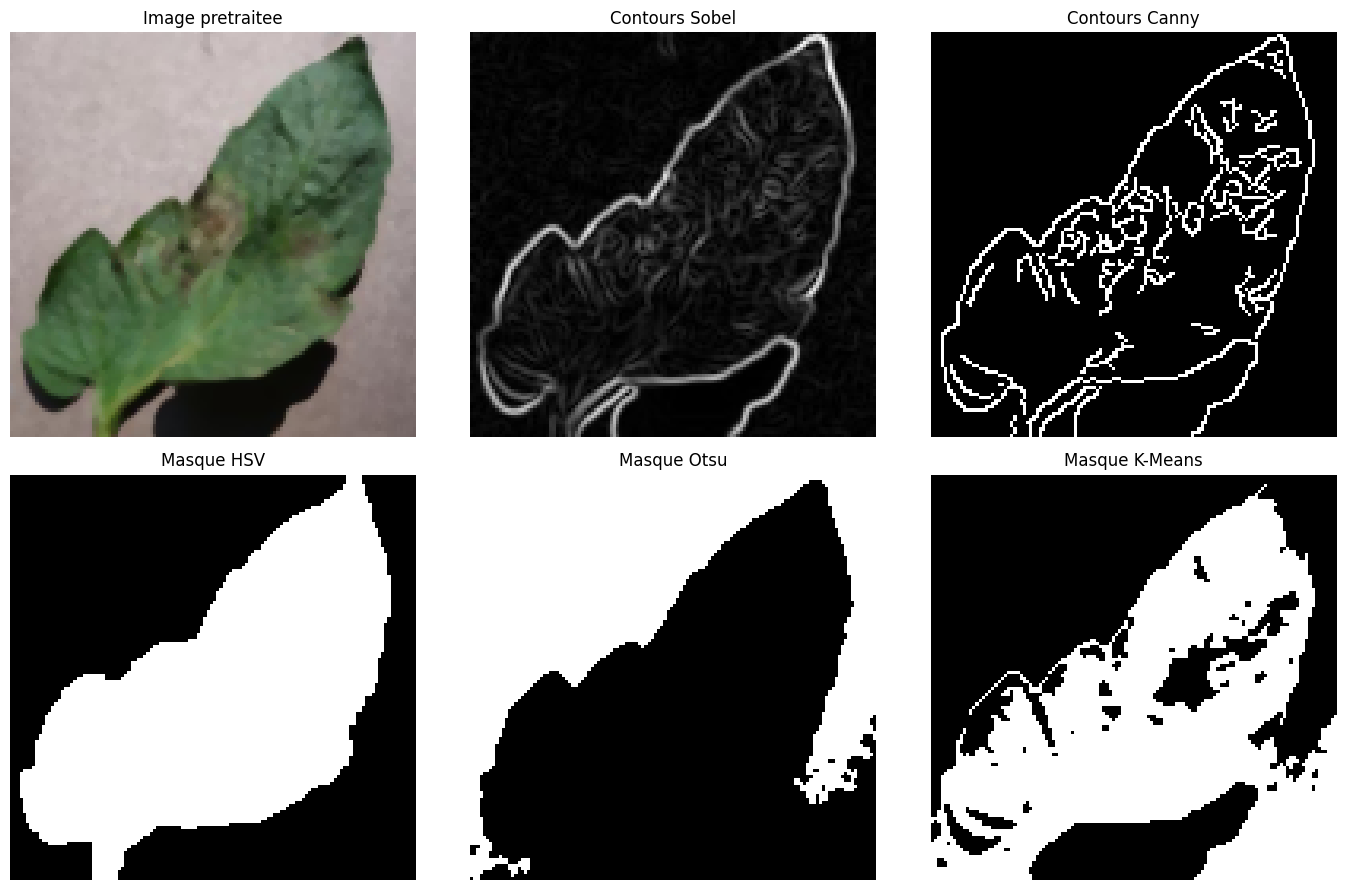

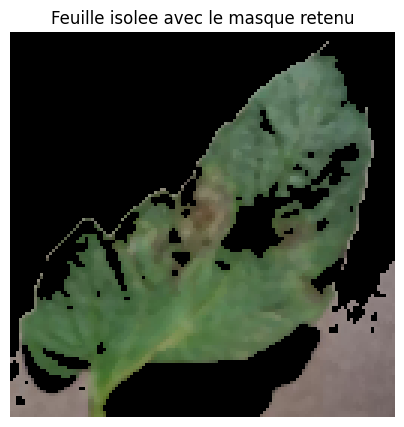

In [11]:
# 9. Comparaison visuelle des methodes de segmentation et contours
if 'processed_image' not in globals():
    assert 'CLASS_NAMES' in globals(), "CLASS_NAMES introuvable. Execute d'abord la cellule 4."
    assert 'DATA_ROOT' in globals(), "DATA_ROOT introuvable. Execute d'abord la cellule 3."
    assert 'preprocess_image' in globals(), "preprocess_image introuvable. Execute d'abord la cellule 6."
    preferred_class = 'Tomato___Late_blight' if 'Tomato___Late_blight' in CLASS_NAMES else CLASS_NAMES[0]
    example_path = sorted((DATA_ROOT / 'test' / preferred_class).glob('*.*'))[0]
    original_image = Image.open(example_path).convert('RGB')
    processed_image = preprocess_image(original_image)

sobel_map = sobel_edge(processed_image)
canny_map = canny_edges(processed_image)
mask_hsv = keep_largest_component(hsv_leaf_mask(processed_image))
mask_otsu = keep_largest_component(otsu_leaf_mask(processed_image))
mask_kmeans = keep_largest_component(kmeans_leaf_mask(processed_image))
mask_selected = choose_leaf_mask(processed_image)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes[0, 0].imshow(processed_image)
axes[0, 0].set_title('Image pretraitee')
axes[0, 1].imshow(sobel_map, cmap='gray')
axes[0, 1].set_title('Contours Sobel')
axes[0, 2].imshow(canny_map, cmap='gray')
axes[0, 2].set_title('Contours Canny')
axes[1, 0].imshow(mask_hsv, cmap='gray')
axes[1, 0].set_title('Masque HSV')
axes[1, 1].imshow(mask_otsu, cmap='gray')
axes[1, 1].set_title('Masque Otsu')
axes[1, 2].imshow(mask_kmeans, cmap='gray')
axes[1, 2].set_title('Masque K-Means')
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()

isolated_leaf = np.array(processed_image) * mask_selected[..., None]
plt.figure(figsize=(5, 5))
plt.imshow(isolated_leaf)
plt.title('Feuille isolee avec le masque retenu')
plt.axis('off')
plt.show()

**Analyse subjective des m?thodes**

- **Sobel** localise bien les variations brusques mais reste ?pais.
- **Canny** donne des contours plus fins, souvent plus lisibles.
- **HSV** fonctionne bien quand le fond n'est pas trop proche de la couleur de la feuille.
- **Otsu** est rapide, mais d?pend fortement du contraste global.
- **K-Means** est int?ressant quand les couleurs sont bien s?par?es, mais peut ?tre moins stable.

Dans ce projet, on retient un masque bas? sur la **meilleure segmentation disponible parmi HSV, Otsu et K-Means**, puis on garde la composante principale.

## 5. Extraction de caract?ristiques classiques

Le vecteur de caract?ristiques demand? dans l'?nonc? contient trois familles:
- **couleur**: histogrammes RGB et HSV,
- **texture**: descripteurs GLCM,
- **forme**: aire, p?rim?tre, circularit?, etc.

In [12]:
# 10. Extraction des features classiques

def build_feature_names() -> list[str]:
    names = []
    for prefix in ['rgb_r', 'rgb_g', 'rgb_b', 'hsv_h', 'hsv_s', 'hsv_v']:
        for i in range(8):
            names.append(f'{prefix}_bin_{i}')
    names += [
        'glcm_contrast',
        'glcm_dissimilarity',
        'glcm_homogeneity',
        'glcm_energy',
        'glcm_correlation',
        'glcm_asm',
        'shape_area',
        'shape_perimeter',
        'shape_circularity',
        'shape_aspect_ratio',
        'shape_extent',
        'shape_mask_ratio',
        'mean_r',
        'mean_g',
        'mean_b',
        'gray_mean',
        'gray_std',
    ]
    return names


FEATURE_NAMES = build_feature_names()


def extract_features(image_path: Path, image_size: int = IMAGE_SIZE):
    image = Image.open(image_path).convert('RGB')
    image = preprocess_image(image, image_size=image_size, denoise=True)
    rgb = np.array(image).astype(np.float32) / 255.0
    hsv = image_to_hsv_array(image).astype(np.float32)
    hsv[..., 0] /= 179.0
    hsv[..., 1] /= 255.0
    hsv[..., 2] /= 255.0
    gray = image_to_gray_array(image)
    mask = choose_leaf_mask(image)

    if mask.sum() == 0:
        mask = np.ones_like(gray, dtype=np.uint8)

    color_parts = []
    for channel in range(3):
        hist, _ = np.histogram(rgb[:, :, channel][mask > 0], bins=8, range=(0, 1))
        color_parts.append(hist.astype(np.float32))
    for channel in range(3):
        hist, _ = np.histogram(hsv[:, :, channel][mask > 0], bins=8, range=(0, 1))
        color_parts.append(hist.astype(np.float32))
    color_features = np.concatenate(color_parts)
    color_features = color_features / (color_features.sum() + 1e-9)

    gray_quantized = (gray // 8).astype(np.uint8)
    glcm = graycomatrix(
        gray_quantized,
        distances=[1],
        angles=[0, np.pi / 4],
        levels=32,
        symmetric=True,
        normed=True,
    )
    texture_features = np.array([
        graycoprops(glcm, 'contrast').mean(),
        graycoprops(glcm, 'dissimilarity').mean(),
        graycoprops(glcm, 'homogeneity').mean(),
        graycoprops(glcm, 'energy').mean(),
        graycoprops(glcm, 'correlation').mean(),
        graycoprops(glcm, 'ASM').mean(),
    ], dtype=np.float32)

    contours, _ = cv2.findContours((mask * 255).astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        contour = max(contours, key=cv2.contourArea)
        area = float(cv2.contourArea(contour))
        perimeter = float(cv2.arcLength(contour, True))
        x, y, w, h = cv2.boundingRect(contour)
        circularity = 0.0 if perimeter == 0 else float((4 * math.pi * area) / (perimeter ** 2 + 1e-9))
        aspect_ratio = float(w / (h + 1e-9))
        extent = float(area / (w * h + 1e-9))
    else:
        area = 0.0
        perimeter = 0.0
        circularity = 0.0
        aspect_ratio = 0.0
        extent = 0.0

    shape_features = np.array([
        area,
        perimeter,
        circularity,
        aspect_ratio,
        extent,
        float(mask.mean()),
    ], dtype=np.float32)

    masked_rgb = rgb[mask > 0] if np.any(mask) else rgb.reshape(-1, 3)
    masked_gray = gray[mask > 0] if np.any(mask) else gray.reshape(-1)
    stats_features = np.array([
        float(masked_rgb[:, 0].mean()),
        float(masked_rgb[:, 1].mean()),
        float(masked_rgb[:, 2].mean()),
        float(masked_gray.mean()),
        float(masked_gray.std()),
    ], dtype=np.float32)

    features = np.concatenate([color_features, texture_features, shape_features, stats_features]).astype(np.float32)
    return features, mask

Dimension du vecteur = 65


,feature,value
0,rgb_r_bin_0,0.000000
1,rgb_r_bin_1,0.007487
2,rgb_r_bin_2,0.095965
3,rgb_r_bin_3,0.035532
4,rgb_r_bin_4,0.027682
5,rgb_r_bin_5,0.000000
6,rgb_r_bin_6,0.000000
7,rgb_r_bin_7,0.000000
8,rgb_g_bin_0,0.000000
9,rgb_g_bin_1,0.000000


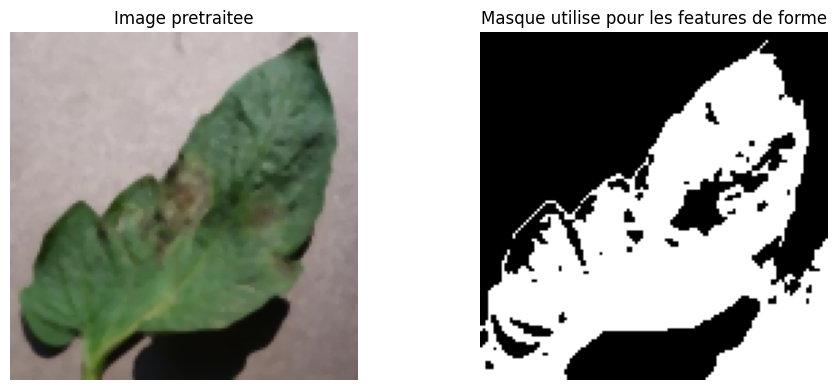

In [13]:
# 11. Exemple de vecteur de features
feature_vector, example_mask = extract_features(example_path)
feature_df = pd.DataFrame({
    'feature': FEATURE_NAMES,
    'value': feature_vector,
})

print('Dimension du vecteur =', feature_vector.shape[0])
display(feature_df.head(15))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(processed_image)
axes[0].set_title('Image pretraitee')
axes[1].imshow(example_mask, cmap='gray')
axes[1].set_title('Masque utilise pour les features de forme')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

**Interpr?tation rapide**

Le vecteur final contient **65 caract?ristiques**. Il reste assez compact pour le Machine Learning tout en couvrant bien les informations demand?es par le sujet.

## 6. Construction du dataset de features

Pour acc?l?rer les relances, le notebook utilise un **cache** dans `artifacts_final/classical_ml/feature_cache.npz`.
- si le cache existe, on le recharge;
- sinon, on extrait les features depuis les images et on le cr?e.

In [14]:
# 12. Construction ou chargement du cache de features

def split_limit(split_name: str, real_count: int) -> int:
    if not FAST_MODE:
        return real_count
    if split_name == 'train':
        return min(real_count, 180)
    if split_name == 'val':
        return min(real_count, 80)
    return min(real_count, 100)



def build_feature_split(split_name: str):
    X_list = []
    y_list = []
    records = []
    start = time.time()
    for class_name in CLASS_NAMES:
        paths = sorted((DATA_ROOT / split_name / class_name).glob('*.*'))
        limit = split_limit(split_name, len(paths))
        for path in paths[:limit]:
            features, _ = extract_features(path)
            X_list.append(features)
            y_list.append(CLASS_TO_IDX[class_name])
            records.append({'split': split_name, 'class_name': class_name, 'path': str(path)})
        print(f'{split_name} | {class_name} | utilisees: {limit}')
    print(f'Extraction {split_name} terminee en {time.time() - start:.1f} s')
    return np.stack(X_list), np.array(y_list), records


if FEATURE_CACHE_PATH.exists() and not REBUILD_FEATURE_CACHE:
    cache = np.load(FEATURE_CACHE_PATH, allow_pickle=True)
    X_train = cache['X_train']
    y_train = cache['y_train']
    X_val = cache['X_val']
    y_val = cache['y_val']
    X_test = cache['X_test']
    y_test = cache['y_test']
    cached_classes = cache['classes'].tolist()
    assert cached_classes == CLASS_NAMES, 'Le cache ne correspond pas aux classes detectees.'
    print('Cache recharge depuis', FEATURE_CACHE_PATH)
else:
    X_train, y_train, _ = build_feature_split('train')
    X_val, y_val, _ = build_feature_split('val')
    X_test, y_test, _ = build_feature_split('test')
    np.savez_compressed(
        FEATURE_CACHE_PATH,
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        classes=np.array(CLASS_NAMES, dtype=object),
    )
    print('Cache cree dans', FEATURE_CACHE_PATH)

print('X_train =', X_train.shape)
print('X_val   =', X_val.shape)
print('X_test  =', X_test.shape)

Cache recharge depuis c:\Users\gharsalli hind\Desktop\Projet_Ing_img\artifacts_final\classical_ml\feature_cache.npz
X_train = (3486, 65)
X_val   = (874, 65)
X_test  = (1092, 65)


## 7. Classification avec Machine Learning

On compare deux candidats rapides et classiques:
- `RandomForest`
- `LinearSVC`

Le meilleur mod?le est choisi sur le **jeu de validation**, puis r?entra?n? sur `train + val` avant l'?valuation finale sur `test`.

In [15]:
# 13. Selection du meilleur modele ML sur le jeu de validation
candidate_models = {
    'RandomForest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            n_jobs=-1,
            class_weight='balanced_subsample',
        )),
    ]),
    'LinearSVC': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LinearSVC(random_state=42, dual=False, max_iter=5000)),
    ]),
}

validation_rows = []
for model_name, model in candidate_models.items():
    model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    validation_rows.append({
        'model': model_name,
        'val_accuracy': accuracy_score(y_val, val_pred),
        'val_macro_f1': f1_score(y_val, val_pred, average='macro'),
    })

validation_df = pd.DataFrame(validation_rows).sort_values(
    by=['val_macro_f1', 'val_accuracy'], ascending=False
).reset_index(drop=True)
display(validation_df)

best_model_name = validation_df.loc[0, 'model']
print('Modele retenu =', best_model_name)

,model,val_accuracy,val_macro_f1
0,RandomForest,0.883295,0.870563
1,LinearSVC,0.850114,0.831225


Modele retenu = RandomForest


In [16]:
# 14. Reentrainement du meilleur modele sur train + val, puis evaluation finale sur test
best_model = candidate_models[best_model_name]
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

best_model.fit(X_trainval, y_trainval)
y_test_pred = best_model.predict(X_test)

ml_metrics = {
    'selected_model': best_model_name,
    'feature_dim': int(X_trainval.shape[1]),
    'test_accuracy': float(accuracy_score(y_test, y_test_pred)),
    'test_macro_f1': float(f1_score(y_test, y_test_pred, average='macro')),
    'test_weighted_f1': float(f1_score(y_test, y_test_pred, average='weighted')),
    'test_precision_weighted': float(precision_score(y_test, y_test_pred, average='weighted', zero_division=0)),
    'test_recall_weighted': float(recall_score(y_test, y_test_pred, average='weighted', zero_division=0)),
}

print(json.dumps(ml_metrics, indent=2))

classification_text = classification_report(
    y_test,
    y_test_pred,
    target_names=CLASS_NAMES,
    zero_division=0,
)
print(classification_text)

{
  "selected_model": "RandomForest",
  "feature_dim": 65,
  "test_accuracy": 0.9029304029304029,
  "test_macro_f1": 0.8961951452828867,
  "test_weighted_f1": 0.9012090814861111,
  "test_precision_weighted": 0.9014425189152319,
  "test_recall_weighted": 0.9029304029304029
}
                       precision    recall  f1-score   support

Tomato___Early_blight       0.83      0.73      0.78       215
 Tomato___Late_blight       0.87      0.91      0.89       375
   Tomato___Leaf_Mold       0.93      0.97      0.95       172
     Tomato___healthy       0.97      0.98      0.98       330

             accuracy                           0.90      1092
            macro avg       0.90      0.89      0.90      1092
         weighted avg       0.90      0.90      0.90      1092



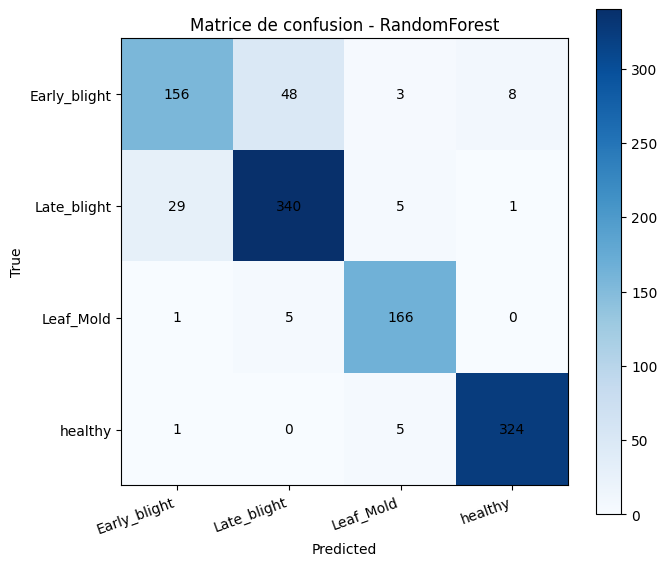

In [17]:
# 15. Matrice de confusion du meilleur modele ML
ml_confusion = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(7, 6))
plt.imshow(ml_confusion, cmap='Blues')
plt.colorbar()
plt.xticks(range(len(CLASS_NAMES)), [name.replace('Tomato___', '') for name in CLASS_NAMES], rotation=20, ha='right')
plt.yticks(range(len(CLASS_NAMES)), [name.replace('Tomato___', '') for name in CLASS_NAMES])
plt.title(f'Matrice de confusion - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('True')
for i in range(ml_confusion.shape[0]):
    for j in range(ml_confusion.shape[1]):
        plt.text(j, i, ml_confusion[i, j], ha='center', va='center', color='black')
plt.tight_layout()
plt.show()

## 8. Comparaison avec le Deep Learning valid?

Le mod?le DL n'est pas r?entra?n? dans ce notebook pour ?viter un temps d'ex?cution inutilement long. On recharge ses r?sultats v?rifi?s depuis `artifacts_final/summary.json`.

In [18]:
# 16. Chargement des resultats Deep Learning verifies
assert DL_SUMMARY_PATH.exists(), f'Fichier introuvable: {DL_SUMMARY_PATH}'
dl_summary = json.loads(DL_SUMMARY_PATH.read_text(encoding='utf-8'))
dl_metrics = dl_summary['mobilenet_v3_transfer']

dl_compact = {
    'model_name': 'MobileNetV3 Transfer',
    'test_accuracy': float(dl_metrics['test_accuracy']),
    'macro_f1': float(dl_metrics['macro_f1']),
    'weighted_f1': float(dl_metrics['weighted_f1']),
}
print(json.dumps(dl_compact, indent=2))

{
  "model_name": "MobileNetV3 Transfer",
  "test_accuracy": 0.956959706959707,
  "macro_f1": 0.9539724539948538,
  "weighted_f1": 0.9563038173947441
}


In [19]:
# 17. Tableau comparatif ML vs DL
comparison_df = pd.DataFrame([
    {
        'famille': 'ML classique',
        'modele': best_model_name,
        'accuracy_test': ml_metrics['test_accuracy'],
        'macro_f1_test': ml_metrics['test_macro_f1'],
        'weighted_f1_test': ml_metrics['test_weighted_f1'],
    },
    {
        'famille': 'Deep Learning',
        'modele': 'MobileNetV3 Transfer',
        'accuracy_test': dl_compact['test_accuracy'],
        'macro_f1_test': dl_compact['macro_f1'],
        'weighted_f1_test': dl_compact['weighted_f1'],
    },
])
comparison_df['gain_accuracy_vs_ml'] = comparison_df['accuracy_test'] - ml_metrics['test_accuracy']
comparison_df['gain_macro_f1_vs_ml'] = comparison_df['macro_f1_test'] - ml_metrics['test_macro_f1']
display(comparison_df)

,famille,modele,accuracy_test,macro_f1_test,weighted_f1_test,gain_accuracy_vs_ml,gain_macro_f1_vs_ml
0,ML classique,RandomForest,0.90293,0.896195,0.901209,0.000000,0.000000
1,Deep Learning,MobileNetV3 Transfer,0.95696,0.953972,0.956304,0.054029,0.057777


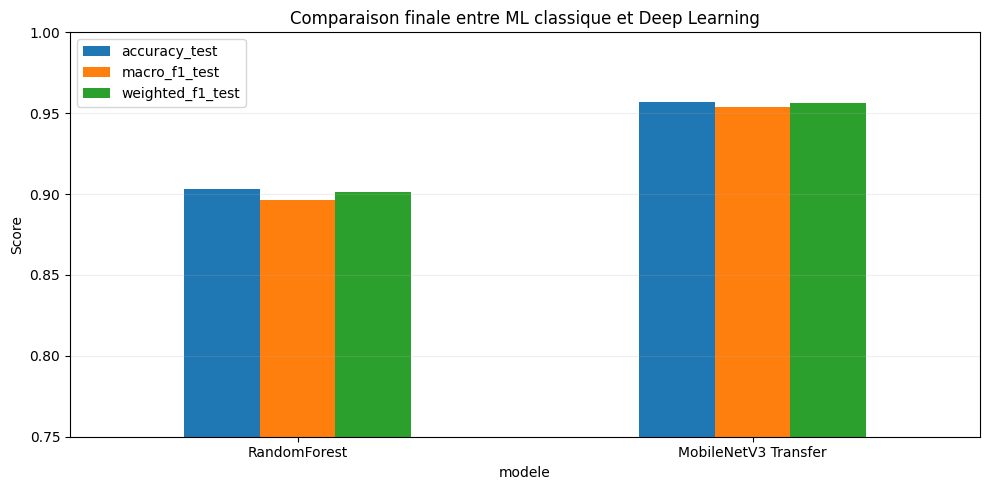

In [20]:
# 18. Visualisation comparative des performances
metric_names = ['accuracy_test', 'macro_f1_test', 'weighted_f1_test']
plot_df = comparison_df.set_index('modele')[metric_names]
plot_df.plot(kind='bar', figsize=(10, 5), ylim=(0.75, 1.0), rot=0)
plt.title('Comparaison finale entre ML classique et Deep Learning')
plt.ylabel('Score')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

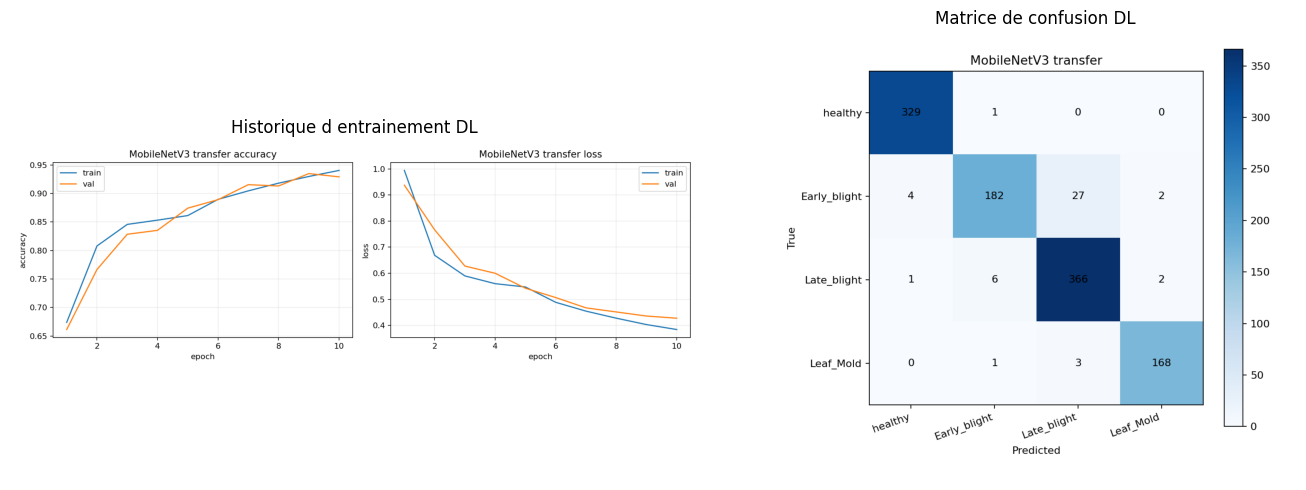

In [21]:
# 19. Affichage des artefacts visuels du modele DL deja valide
history_path = ARTIFACT_ROOT / 'mobilenet_v3_transfer' / 'history.png'
dl_cm_path = ARTIFACT_ROOT / 'mobilenet_v3_transfer' / 'confusion_matrix.png'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(plt.imread(history_path))
axes[0].set_title('Historique d entrainement DL')
axes[1].imshow(plt.imread(dl_cm_path))
axes[1].set_title('Matrice de confusion DL')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 9. Conclusion acad?mique

### Ce que montre le notebook
- le pipeline classique fonctionne r?ellement de bout en bout;
- les ?tapes de pr?traitement, segmentation et extraction de caract?ristiques sont visibles et justifi?es;
- le mod?le ML classique obtient des r?sultats solides;
- le mod?le DL reste sup?rieur, ce qui confirme l'int?r?t des approches profondes sur ce probl?me.

### Lecture honn?te des r?sultats
- le **ML classique** est plus simple ? expliquer et plus l?ger ? entra?ner;
- le **DL** donne les meilleures performances en classification finale;
- pour une note ?lev?e, il faut bien expliquer pendant la discussion **pourquoi** le DL gagne malgr? un pipeline classique correct.

In [22]:
# 20. Resume final pret a reutiliser dans le rapport
ml_acc = ml_metrics['test_accuracy']
ml_f1 = ml_metrics['test_macro_f1']
dl_acc = dl_compact['test_accuracy']
dl_f1 = dl_compact['macro_f1']

print('Resume final')
print('-' * 60)
print(f'Modele ML retenu : {best_model_name}')
print(f'Accuracy ML test : {ml_acc:.4f}')
print(f'Macro F1 ML test : {ml_f1:.4f}')
print(f'Accuracy DL test : {dl_acc:.4f}')
print(f'Macro F1 DL test : {dl_f1:.4f}')
print(f'Gain accuracy DL - ML : {dl_acc - ml_acc:.4f}')
print(f'Gain macro F1 DL - ML : {dl_f1 - ml_f1:.4f}')

if dl_acc > ml_acc:
    print('Conclusion courte: le Deep Learning est le meilleur choix final pour ce projet.')
else:
    print('Conclusion courte: le Machine Learning classique reste competitif sur cette selection de classes.')

Resume final
------------------------------------------------------------
Modele ML retenu : RandomForest
Accuracy ML test : 0.9029
Macro F1 ML test : 0.8962
Accuracy DL test : 0.9570
Macro F1 DL test : 0.9540
Gain accuracy DL - ML : 0.0540
Gain macro F1 DL - ML : 0.0578
Conclusion courte: le Deep Learning est le meilleur choix final pour ce projet.
